# BTC 永续合约持仓 / 杠杆数据 — 信号视觉探索

**目的**：把昨天（2026-09-08）Spider 新入库的合约数据画出来，和价格、底座（gate_only / V1）的回撤 episode 放在同一条时间线上，**先看，再提假设**。

数据源（`192.168.1.68/ginkgo_bole`，全部 UTC）：

| 数据 | 表 | 覆盖 | 说明 |
|---|---|---|---|
| K 线 4h / 1d | `crypto_kline_4h` / `crypto_kline_1d` | 2021-01 → 今 | 连续聚合视图 |
| 资金费率（结算） | `crypto_funding_binance` source=settled | 2021-01 → 今 | 每 8h 一次 |
| 持仓量 OI | `crypto_open_interest_binance` | 2021-01 → 今 | 5min |
| **多空比 × 4**（新） | `crypto_position_ratio_binance` | 2020-09 → 今 | top_account / top_position / global_account / taker_vol，5min |
| 爆仓 5min 聚合（新） | `crypto_liquidation_5min` | **2026-04-10 → 今** | WS 采样，**只是下界 / 强度代理** |
| 恐惧贪婪指数 | `crypto_fear_greed_index` | 2018-02 → 今 | 日频 |

**四个比率的含义**（Binance 口径，全部是 *多/空*，1 = 中性）：
- `top_account`：大户（前 20% 保证金）中做多账户数 / 做空账户数
- `top_position`：大户多头持仓量 / 空头持仓量
- `global_account`：全体账户中做多账户数 / 做空账户数（"散户情绪"）
- `taker_vol`：主动买入量 / 主动卖出量（5min，噪声大，本 notebook 用 4h 均值）

**纪律（来自 `tasks/lessons.md`）**：
1. 本 notebook 是"看图提假设"阶段，**不出 PASS/FAIL 结论**。真正的验收走 `scripts/signal_ic_probe.py`（三折同号 + 最近折不反号）和 `scripts/backtest_rules.py`（§1.1）。
2. 设计文档已预登记 **H4a（大户持仓拥挤反转）/ H4b（散户 vs 大户分歧）/ H5（主动买卖失衡）**，见 GinkgoRoad《合约持仓与杠杆数据-采集增量-设计》§8。看图之后新提的假设，必须先写下方向再跑探针。
3. 条件统计（§5）默认只用 **前两折**（`EXPLORE_END` 之前），最近一折留出；这是防止"看着最近的数据凑规则"。
4. 做风控假设前先看底座回撤 episode 的时间线（§1）——上一轮 H1/H2 的教训。

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sqlalchemy import text

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))
from utils.db import get_contract_engine, read_funding
from utils.splits import time_folds

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["font.family"] = ["Noto Sans CJK JP", "DejaVu Sans"]   # Noto CJK .ttc 在 matplotlib 里只注册了 JP 面，中文字形齐全
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.width", 160)

# ─── 参数 ────────────────────────────────────────────────────────────────────
SYMBOL       = "BTC/USDT"
START        = "2021-01-01"          # K 线 / funding / OI 的 DB 起点
TF           = "4h"
BARS_PER_DAY = int(pd.Timedelta("1D") / pd.Timedelta(TF))
Z_WINDOW     = "90D"                 # z-score 回看窗口（与 H2a oi_level_90d_z 一致）
N_EPISODES   = 4                     # 标出底座最深的几段回撤
EXPLORE_END  = None                  # None → 自动取第三折起点（最近折留出）；可手动如 "2025-04-01"
HORIZONS     = {"1d": 1 * BARS_PER_DAY, "3d": 3 * BARS_PER_DAY, "7d": 7 * BARS_PER_DAY}

EPISODE_COLOR = "rgba(220, 40, 40, 0.10)"

## 0. 读取与对齐

所有序列都对齐到 **bar 收盘时刻可知** 的值：

- 4h / 1d 桶内的 OI、比率取 **桶末值**（`last`），与 H2a 的做法一致；`taker_vol` 另取桶内均值
- 结算 funding 用 `merge_asof` 贴到 `funding_time ≤ bar 收盘` 的最近一次
- 日线状态（gate / V1）在 UTC 日收盘后才可知，同样用 asof 贴到 4h

In [2]:
ENG = get_contract_engine()

def sql(q: str, **params) -> pd.DataFrame:
    with ENG.connect() as conn:
        return pd.read_sql(text(q), conn, params=params)

def _num(df: pd.DataFrame, cols) -> pd.DataFrame:
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def load_kline(bucket: str) -> pd.DataFrame:
    view = {"4h": "crypto_kline_4h", "1d": "crypto_kline_1d"}[bucket]
    df = sql(f"SELECT open_time AS ts, open, high, low, close, volume FROM {view} "
             f"WHERE symbol = :s AND open_time >= :start ORDER BY open_time",
             s=SYMBOL, start=START)
    df = _num(df, ["open", "high", "low", "close", "volume"])
    df["ts"] = pd.to_datetime(df["ts"], utc=True)
    df["close_time"] = df["ts"] + pd.Timedelta(bucket)
    return df

def load_oi(bucket: str) -> pd.DataFrame:
    tb = {"4h": "4 hours", "1d": "1 day"}[bucket]
    df = sql(f"SELECT time_bucket(:tb, bucket_time) AS ts, "
             f"       last(sum_open_interest_value, bucket_time) AS oi_value, "
             f"       last(sum_open_interest, bucket_time) AS oi_base "
             f"FROM crypto_open_interest_binance WHERE symbol = :s AND bucket_time >= :start "
             f"GROUP BY 1 ORDER BY 1", tb=tb, s=SYMBOL, start=START)
    df["ts"] = pd.to_datetime(df["ts"], utc=True)
    return _num(df, ["oi_value", "oi_base"])

def load_ratios(bucket: str) -> pd.DataFrame:
    tb = {"4h": "4 hours", "1d": "1 day"}[bucket]
    long = sql(f"SELECT time_bucket(:tb, bucket_time) AS ts, ratio_type, "
               f"       last(ratio, bucket_time) AS last_v, avg(ratio) AS mean_v, count(*) AS n "
               f"FROM crypto_position_ratio_binance WHERE symbol = :s AND bucket_time >= :start "
               f"GROUP BY 1, 2 ORDER BY 1", tb=tb, s=SYMBOL, start=START)
    long["ts"] = pd.to_datetime(long["ts"], utc=True)
    long = _num(long, ["last_v", "mean_v"])
    wide = long.pivot(index="ts", columns="ratio_type", values="last_v")
    wide["taker_vol_mean"] = long[long.ratio_type == "taker_vol"].set_index("ts")["mean_v"]
    wide["ratio_n"] = long.groupby("ts")["n"].sum()
    return wide.reset_index()

def load_liq(bucket: str) -> pd.DataFrame:
    tb = {"4h": "4 hours", "1d": "1 day"}[bucket]
    df = sql(f"SELECT time_bucket(:tb, bucket_time) AS ts, side, sum(cost_sum) AS usd, sum(n_orders) AS n "
             f"FROM crypto_liquidation_5min WHERE symbol = :s GROUP BY 1, 2 ORDER BY 1",
             tb=tb, s=SYMBOL)
    df["ts"] = pd.to_datetime(df["ts"], utc=True)
    df = _num(df, ["usd"])
    # side='sell' = 多头被强平；'buy' = 空头被强平
    w = df.pivot(index="ts", columns="side", values="usd").rename(
        columns={"sell": "liq_long_usd", "buy": "liq_short_usd"})
    return w.reset_index()

def load_funding_settled() -> pd.DataFrame:
    df = read_funding(SYMBOL, start=START, source="settled", prefer_origin=("fapi_settled",))
    df = df.rename(columns={"timestamp": "ts"})[["ts", "funding_rate"]]
    df["ts"] = pd.to_datetime(df["ts"], utc=True)
    df["funding_rate"] = pd.to_numeric(df["funding_rate"], errors="coerce")
    n7, n30 = 3 * 7, 3 * 30                                   # 每天 3 次结算
    df["funding_cum_7d"]  = df["funding_rate"].rolling(n7,  min_periods=n7 // 2).sum()
    df["funding_cum_30d"] = df["funding_rate"].rolling(n30, min_periods=n30 // 2).sum()
    return df

def load_fng() -> pd.DataFrame:
    df = sql("SELECT date, value AS fng FROM crypto_fear_greed_index WHERE date >= :start ORDER BY date",
             start=START)
    df["ts"] = pd.to_datetime(df["date"], utc=True)      # 当日 00:00 UTC 发布
    return df[["ts", "fng"]]

k4, k1 = load_kline("4h"), load_kline("1d")
oi4, oi1 = load_oi("4h"), load_oi("1d")
r4, r1 = load_ratios("4h"), load_ratios("1d")
liq4, liq1 = load_liq("4h"), load_liq("1d")
fund = load_funding_settled()
fng = load_fng()

coverage = pd.DataFrame({
    name: {"rows": len(df), "first": df["ts"].min(), "last": df["ts"].max()}
    for name, df in {"kline_4h": k4, "kline_1d": k1, "oi_4h": oi4, "ratios_4h": r4,
                     "liq_4h": liq4, "funding_settled": fund, "fear_greed": fng}.items()
}).T
coverage

,rows,first,last
kline_4h,12462,2021-01-01 00:00:00+00:00,2026-09-08 20:00:00+00:00
kline_1d,2077,2021-01-01 00:00:00+00:00,2026-09-08 00:00:00+00:00
oi_4h,12460,2021-01-01 00:00:00+00:00,2026-09-08 20:00:00+00:00
ratios_4h,12343,2020-12-31 16:00:00+00:00,2026-09-08 20:00:00+00:00
liq_4h,912,2026-04-10 00:00:00+00:00,2026-09-08 20:00:00+00:00
funding_settled,6231,2021-01-01 00:00:00+00:00,2026-09-08 16:00:00+00:00
fear_greed,2076,2021-01-01 00:00:00+00:00,2026-09-08 00:00:00+00:00


In [3]:
def assemble(k, oi, r, liq, bucket: str) -> pd.DataFrame:
    df = k.merge(oi, on="ts", how="left").merge(r, on="ts", how="left").merge(liq, on="ts", how="left")
    # 结算 funding / F&G：贴到 bar 收盘时刻之前的最近一次
    df = pd.merge_asof(df.sort_values("close_time"), fund.rename(columns={"ts": "f_ts"}).sort_values("f_ts"),
                       left_on="close_time", right_on="f_ts", direction="backward").drop(columns="f_ts")
    df = pd.merge_asof(df.sort_values("close_time"), fng.rename(columns={"ts": "g_ts"}).sort_values("g_ts"),
                       left_on="close_time", right_on="g_ts", direction="backward").drop(columns="g_ts")
    df["log_close"] = np.log(df["close"])
    return df.sort_values("ts").reset_index(drop=True)

f = assemble(k4, oi4, r4, liq4, "4h")     # 4h 主表
d = assemble(k1, oi1, r1, liq1, "1d")     # 日线表（overview / 底座）
print(f"4h rows={len(f)}  1d rows={len(d)}")
missing = f[["oi_value", "top_position", "top_account", "global_account", "taker_vol", "funding_rate"]].isna().mean()
print("4h 缺失率:\n", missing.round(4).to_string())

4h rows=12462  1d rows=2077
4h 缺失率:
 oi_value          0.0002
top_position      0.1537
top_account       0.1537
global_account    0.0097
taker_vol         0.0623
funding_rate      0.0000


### 0.1 逐月覆盖率（不填零，缺口就让它露出来）

Vision 归档在 2022 年有洞：`top_account` / `top_position` 缺 2–4 月，`top_position` 还缺 7–11 月；`taker_vol` 缺 2–4 月。
四个比率都干净的窗口从 **2023-01** 起。下面的热力图是每月实际 4h 桶数 / 应有桶数。

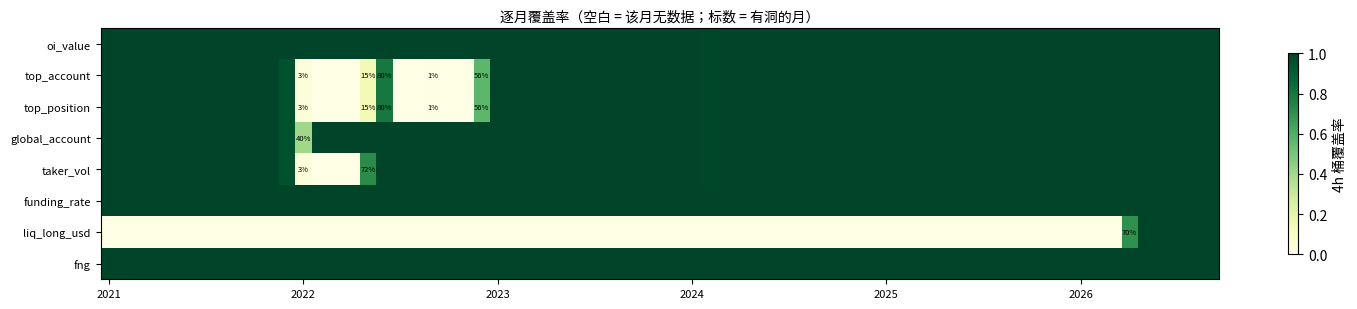

In [4]:
COV_COLS = ["oi_value", "top_account", "top_position", "global_account", "taker_vol", "funding_rate", "liq_long_usd", "fng"]
month = f["ts"].dt.tz_localize(None).dt.to_period("M")
cov = f.groupby(month)[COV_COLS].apply(lambda g: g.notna().mean()).T
fig, ax = plt.subplots(figsize=(max(10, 0.22 * cov.shape[1]), 3.2))
im = ax.imshow(cov.values, aspect="auto", cmap="YlGn", vmin=0, vmax=1)
ax.set_yticks(range(len(COV_COLS)), COV_COLS, fontsize=8)
xt = [i for i, p in enumerate(cov.columns) if p.month == 1]
ax.set_xticks(xt, [str(cov.columns[i].year) for i in xt], fontsize=8)
for i in range(cov.shape[0]):
    for j in range(cov.shape[1]):
        v = cov.values[i, j]
        if 0 < v < 0.95:
            ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=5.5)
fig.colorbar(im, ax=ax, shrink=0.8, label="4h 桶覆盖率")
ax.set_title("逐月覆盖率（空白 = 该月无数据；标数 = 有洞的月）", fontsize=10)
fig.tight_layout(); plt.show()

## 1. 底座与回撤 episode（先看这里）

`gate_only`：UTC 日收盘 > SMA200 → 100%，否则 0%。`V1`：再加一条 日收盘 ≥ SMA50，否则清仓。
这里用日线**无成本**复现，只用于标出 episode 的时间位置；精确数字以 `backtest_rules.py` 为准。

问题清单（看图时带着）：
- 每段回撤里，**哪个序列在回撤开始前就已经异常**？（有资格做风控）
- 哪个序列只是在回撤中途跟着价格动？（最多是收益增强，不是风控）
- V1 已经避开的那部分回撤，剩下的那部分是什么形态？

In [5]:
d["sma200"] = d["close"].rolling(200).mean()
d["sma50"]  = d["close"].rolling(50).mean()
d["gate"]   = (d["close"] > d["sma200"]).astype(float)
d["v1"]     = ((d["close"] > d["sma200"]) & (d["close"] >= d["sma50"])).astype(float)
d["ret"]    = d["close"].pct_change()
for name in ("gate", "v1"):
    d[f"eq_{name}"] = (1 + d[name].shift(1).fillna(0) * d["ret"]).cumprod()
    d[f"dd_{name}"] = d[f"eq_{name}"] / d[f"eq_{name}"].cummax() - 1
d["eq_bh"] = d["close"] / d["close"].iloc[0]
d["dd_bh"] = d["eq_bh"] / d["eq_bh"].cummax() - 1

def drawdown_episodes(ts: pd.Series, dd: pd.Series, n: int) -> pd.DataFrame:
    '''把 dd<0 的连续段切成 episode：peak（前一个新高日）→ trough → end（回到新高或数据末尾）。'''
    under = (dd < 0).values
    rows, i = [], 0
    while i < len(under):
        if not under[i]:
            i += 1; continue
        j = i
        while j < len(under) and under[j]:
            j += 1
        seg = dd.iloc[i:j]
        rows.append({"peak": ts.iloc[max(i - 1, 0)], "trough": ts.iloc[seg.idxmin()],
                     "end": ts.iloc[j - 1], "depth": seg.min(), "days": j - i,
                     "recovered": j < len(under)})
        i = j
    out = pd.DataFrame(rows).sort_values("depth").head(n).reset_index(drop=True)
    out["peak_to_trough_days"] = (out["trough"] - out["peak"]).dt.days
    return out

ep_gate = drawdown_episodes(d["ts"], d["dd_gate"], N_EPISODES)
ep_v1   = drawdown_episodes(d["ts"], d["dd_v1"], N_EPISODES)
print("gate_only 最深回撤 episode：")
display(ep_gate.assign(depth=lambda x: (x.depth * 100).round(1)))
print("V1 最深回撤 episode：")
display(ep_v1.assign(depth=lambda x: (x.depth * 100).round(1)))

gate_only 最深回撤 episode：


,peak,trough,end,depth,days,recovered,peak_to_trough_days
0,2021-11-08 00:00:00+00:00,2021-12-28 00:00:00+00:00,2023-07-02 00:00:00+00:00,-35.8,601,True,50
1,2025-01-21 00:00:00+00:00,2025-03-28 00:00:00+00:00,2026-09-08 00:00:00+00:00,-31.0,595,False,66
2,2024-03-13 00:00:00+00:00,2024-09-30 00:00:00+00:00,2024-11-10 00:00:00+00:00,-25.0,242,True,201
3,2021-09-06 00:00:00+00:00,2021-10-02 00:00:00+00:00,2021-10-18 00:00:00+00:00,-24.9,42,True,26


V1 最深回撤 episode：


,peak,trough,end,depth,days,recovered,peak_to_trough_days
0,2021-09-06 00:00:00+00:00,2021-10-02 00:00:00+00:00,2021-10-18 00:00:00+00:00,-24.9,42,True,26
1,2024-03-13 00:00:00+00:00,2024-09-30 00:00:00+00:00,2024-11-10 00:00:00+00:00,-23.3,242,True,201
2,2024-12-17 00:00:00+00:00,2025-02-04 00:00:00+00:00,2025-07-12 00:00:00+00:00,-16.7,207,True,49
3,2021-11-08 00:00:00+00:00,2021-11-18 00:00:00+00:00,2023-01-28 00:00:00+00:00,-15.7,446,True,10


In [6]:
def add_episodes(fig, episodes: pd.DataFrame, color=EPISODE_COLOR):
    for _, e in episodes.iterrows():
        fig.add_vrect(x0=e["peak"], x1=e["end"], fillcolor=color, opacity=1, line_width=0, layer="below")
        fig.add_vline(x=e["trough"], line_width=1, line_dash="dot", line_color="rgba(200,0,0,0.5)")

fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.03,
                    row_heights=[0.55, 0.25, 0.2],
                    subplot_titles=("BTC 日线（log）+ SMA50/200；红色阴影 = gate_only 最深回撤 episode",
                                    "净值（无成本复现）", "回撤"))
fig.add_trace(go.Scatter(x=d.ts, y=d.close, name="close", line=dict(color="#222", width=1)), 1, 1)
fig.add_trace(go.Scatter(x=d.ts, y=d.sma50, name="SMA50", line=dict(color="#e69f00", width=1)), 1, 1)
fig.add_trace(go.Scatter(x=d.ts, y=d.sma200, name="SMA200", line=dict(color="#0072b2", width=1)), 1, 1)
for name, col in (("eq_bh", "#999"), ("eq_gate", "#0072b2"), ("eq_v1", "#009e73")):
    fig.add_trace(go.Scatter(x=d.ts, y=d[name], name=name, line=dict(color=col, width=1.2)), 2, 1)
for name, col in (("dd_gate", "#0072b2"), ("dd_v1", "#009e73")):
    fig.add_trace(go.Scatter(x=d.ts, y=d[name], name=name, line=dict(color=col, width=1), fill="tozeroy"), 3, 1)
add_episodes(fig, ep_gate)
fig.update_yaxes(type="log", row=1, col=1)
fig.update_yaxes(tickformat=".0%", row=3, col=1)
fig.update_layout(height=820, template="plotly_white", legend=dict(orientation="h", y=1.04),
                  margin=dict(l=40, r=20, t=60, b=30), hovermode="x unified")
fig.show()

## 2. 全景：价格 × 五类持仓/杠杆数据（日线分辨率）

日线取每日桶末值，所以只看**形态与相位**，细节到 §4 的 4h 放大图看。所有子图共享 x 轴、可拖动缩放；红色阴影同上。

看图提示：
- `top_position` 与 OI 名义价值是否几乎同步？（H4a 与 H2a 的同源性问题，§5 有相关系数）
- `global_account − top_account` 为正 = 散户比大户更看多。它在回撤开始前是什么状态？
- `taker_vol` 均值偏离 1 的幅度是否有"先于价格"的时刻？
- 2024-01 ETF 之后 funding 的形态是否变了？（H1 关闭的原因是 f2 折反号）

In [7]:
def add_state_strip(fig, ts, state, row, name):
    fig.add_trace(go.Heatmap(x=ts, y=[name], z=[state.values], showscale=False,
                             colorscale=[[0, "#f0f0f0"], [0.5, "#a6cee3"], [1, "#1f78b4"]],
                             zmin=0, zmax=1, hovertemplate="%{x}<br>" + name + "=%{z}<extra></extra>"),
                  row, 1)

d["retail_minus_top"] = d["global_account"] - d["top_account"]
d["taker_dev"] = d["taker_vol_mean"] - 1

panels = [
    ("close",            "价格（log）",                    "#222",    dict(type="log")),
    ("state",            "gate / V1 状态",                 None,      None),
    ("funding_rate",     "结算 funding（每 8h）",           "#d55e00", None),
    ("oi_value",         "OI 名义价值 (USDT)",              "#0072b2", None),
    ("top_position",     "大户持仓多空比 top_position",     "#6a3d9a", None),
    ("top_account",      "大户账户多空比 top_account",      "#984ea3", None),
    ("global_account",   "全体账户多空比 global_account",   "#377eb8", None),
    ("retail_minus_top", "global − top（散户比大户更多头）", "#4daf4a", None),
    ("taker_dev",        "taker 买卖比日均 − 1",            "#e41a1c", None),
    ("liq",              "爆仓 USDT（下界，2026-04 起）",   None,      None),
    ("fng",              "恐惧贪婪指数",                    "#ff7f00", None),
]
heights = [0.2, 0.04] + [0.076] * (len(panels) - 2)
fig = make_subplots(rows=len(panels), cols=1, shared_xaxes=True, vertical_spacing=0.012,
                    row_heights=heights, subplot_titles=[p[1] for p in panels])
for i, (col, title, color, yax) in enumerate(panels, start=1):
    if col == "state":
        add_state_strip(fig, d.ts, d["gate"] * 0.5 + d["v1"] * 0.5, i, "gate/V1")
    elif col == "liq":
        fig.add_trace(go.Bar(x=d.ts, y=d["liq_long_usd"], name="多头爆仓", marker_color="#e41a1c"), i, 1)
        fig.add_trace(go.Bar(x=d.ts, y=-d["liq_short_usd"], name="空头爆仓", marker_color="#4daf4a"), i, 1)
    else:
        fig.add_trace(go.Scatter(x=d.ts, y=d[col], name=col, line=dict(color=color, width=1)), i, 1)
        if col in ("top_position", "top_account", "global_account", "retail_minus_top", "taker_dev", "funding_rate"):
            fig.add_hline(y=0 if col in ("retail_minus_top", "taker_dev", "funding_rate") else 1,
                          line_width=0.8, line_color="#888", row=i, col=1)
    if yax:
        fig.update_yaxes(row=i, col=1, **yax)
add_episodes(fig, ep_gate)
fig.update_layout(height=1900, template="plotly_white", showlegend=False, barmode="relative",
                  margin=dict(l=50, r=20, t=40, b=30), hovermode="x unified")
fig.update_annotations(font_size=11)
fig.show()

## 3. 标准化视角：90 天 z-score（日线）

原始比率有长期漂移（例如 `top_position` 2021 vs 2025 的基准水平不同），做规则时用的是 **相对自身近期分布的位置**。这里把候选特征统一做 90 天滚动 z-score，和 episode 对齐看。

也把 H2a 的 `oi_level_90d_z` 放进来做对照：如果 `top_position_z` 和它几乎重合，H4a 就不是新信息。

In [8]:
def zscore(s: pd.Series, window: str, bucket: str) -> pd.Series:
    n = int(pd.Timedelta(window) / pd.Timedelta(bucket))
    r = s.rolling(n, min_periods=n // 2)
    return (s - r.mean()) / r.std()

def add_features(df: pd.DataFrame, bucket: str) -> pd.DataFrame:
    df = df.copy()
    df["retail_minus_top"] = df["global_account"] - df["top_account"]
    df["taker_dev"] = df["taker_vol_mean"] - 1
    df["oi_log"] = np.log(df["oi_value"].where(df["oi_value"] > 0))
    df["oi_z"]               = zscore(df["oi_log"], Z_WINDOW, bucket)
    df["top_position_z"]     = zscore(df["top_position"], Z_WINDOW, bucket)
    df["top_account_z"]      = zscore(df["top_account"], Z_WINDOW, bucket)
    df["global_account_z"]   = zscore(df["global_account"], Z_WINDOW, bucket)
    df["retail_minus_top_z"] = zscore(df["retail_minus_top"], Z_WINDOW, bucket)
    df["taker_dev_z"]        = zscore(df["taker_dev"], "30D", bucket)
    df["funding_cum_7d_z"]   = zscore(df["funding_cum_7d"], Z_WINDOW, bucket)
    liq_tot = df["liq_long_usd"].fillna(0) + df["liq_short_usd"].fillna(0)
    df["liq_imbalance"] = ((df["liq_short_usd"].fillna(0) - df["liq_long_usd"].fillna(0)) / liq_tot.replace(0, np.nan))
    return df

d = add_features(d, "1d")
f = add_features(f, "4h")
Z_FEATURES = ["oi_z", "top_position_z", "top_account_z", "global_account_z",
              "retail_minus_top_z", "taker_dev_z", "funding_cum_7d_z"]

fig = make_subplots(rows=len(Z_FEATURES) + 1, cols=1, shared_xaxes=True, vertical_spacing=0.015,
                    row_heights=[0.22] + [0.78 / len(Z_FEATURES)] * len(Z_FEATURES),
                    subplot_titles=["价格（log）"] + Z_FEATURES)
fig.add_trace(go.Scatter(x=d.ts, y=d.close, line=dict(color="#222", width=1), name="close"), 1, 1)
fig.update_yaxes(type="log", row=1, col=1)
for i, col in enumerate(Z_FEATURES, start=2):
    fig.add_trace(go.Scatter(x=d.ts, y=d[col], line=dict(width=1), name=col), i, 1)
    for lvl in (-2, 2):
        fig.add_hline(y=lvl, line_width=0.6, line_dash="dash", line_color="#aaa", row=i, col=1)
    fig.add_hline(y=0, line_width=0.6, line_color="#888", row=i, col=1)
    fig.update_yaxes(range=[-3.5, 3.5], row=i, col=1)
add_episodes(fig, ep_gate)
fig.update_layout(height=1500, template="plotly_white", showlegend=False,
                  margin=dict(l=50, r=20, t=40, b=30), hovermode="x unified")
fig.update_annotations(font_size=11)
fig.show()

## 4. 逐段放大：底座最深的几次回撤（4h 分辨率）

每段取 `peak − 30 天` 到 `trough + 30 天`（修复期不看，风控只关心下跌前后）。竖线：橙 = 净值峰值（回撤开始），红 = 谷底。
重点看 **橙线左侧** 各序列的状态——那才是规则能用上的信息。

In [9]:
ZOOM_PANELS = [
    ("close",            "价格 + SMA50/200",         "#222"),
    ("oi_value",         "OI 名义价值",               "#0072b2"),
    ("top_position",     "top_position",             "#6a3d9a"),
    ("top_account",      "top_account",              "#984ea3"),
    ("global_account",   "global_account",           "#377eb8"),
    ("retail_minus_top", "global − top",             "#4daf4a"),
    ("taker_dev",        "taker 4h 均值 − 1",        "#e41a1c"),
    ("funding_rate",     "结算 funding",             "#d55e00"),
    ("liq",              "爆仓 USDT（若有）",         None),
]

f_daily_state = pd.merge_asof(
    f[["ts", "close_time"]].sort_values("close_time"),
    d[["close_time", "sma50", "sma200", "gate", "v1"]].rename(columns={"close_time": "d_close"}).sort_values("d_close"),
    left_on="close_time", right_on="d_close", direction="backward").drop(columns="d_close")
for c in ("sma50", "sma200", "gate", "v1"):
    f[c] = f_daily_state[c].values

def zoom_episode(e: pd.Series, title: str):
    lo, hi = e["peak"] - pd.Timedelta("30D"), e["trough"] + pd.Timedelta("30D")
    w = f[(f.ts >= lo) & (f.ts <= hi)]
    has_liq = w["liq_long_usd"].notna().any()
    panels = [p for p in ZOOM_PANELS if p[0] != "liq" or has_liq]
    fig = make_subplots(rows=len(panels), cols=1, shared_xaxes=True, vertical_spacing=0.015,
                        row_heights=[0.3] + [0.7 / (len(panels) - 1)] * (len(panels) - 1),
                        subplot_titles=[p[1] for p in panels])
    for i, (col, _, color) in enumerate(panels, start=1):
        if col == "close":
            fig.add_trace(go.Candlestick(x=w.ts, open=w.open, high=w.high, low=w.low, close=w.close,
                                         name="4h", increasing_line_width=1, decreasing_line_width=1), 1, 1)
            fig.add_trace(go.Scatter(x=w.ts, y=w.sma50, name="SMA50", line=dict(color="#e69f00", width=1)), 1, 1)
            fig.add_trace(go.Scatter(x=w.ts, y=w.sma200, name="SMA200", line=dict(color="#0072b2", width=1)), 1, 1)
        elif col == "liq":
            fig.add_trace(go.Bar(x=w.ts, y=w["liq_long_usd"], marker_color="#e41a1c", name="多头爆仓"), i, 1)
            fig.add_trace(go.Bar(x=w.ts, y=-w["liq_short_usd"], marker_color="#4daf4a", name="空头爆仓"), i, 1)
        else:
            fig.add_trace(go.Scatter(x=w.ts, y=w[col], name=col, line=dict(color=color, width=1)), i, 1)
            if col in ("retail_minus_top", "taker_dev", "funding_rate"):
                fig.add_hline(y=0, line_width=0.8, line_color="#888", row=i, col=1)
            elif col in ("top_position", "top_account", "global_account"):
                fig.add_hline(y=1, line_width=0.8, line_color="#888", row=i, col=1)
    fig.add_vline(x=e["peak"], line_color="#e69f00", line_width=1.5)
    fig.add_vline(x=e["trough"], line_color="#d62728", line_width=1.5)
    fig.add_vrect(x0=e["peak"], x1=e["end"], fillcolor=EPISODE_COLOR, line_width=0, layer="below")
    fig.update_layout(title=title, height=1500, template="plotly_white", showlegend=False,
                      xaxis_rangeslider_visible=False, barmode="relative",
                      margin=dict(l=50, r=20, t=60, b=30), hovermode="x unified")
    fig.update_annotations(font_size=11)
    fig.show()

for k, e in ep_gate.iterrows():
    zoom_episode(e, f"gate_only 回撤 #{k + 1}: {e['peak'].date()} → {e['trough'].date()} "
                    f"({e['depth'] * 100:.1f}%, 峰到谷 {e['peak_to_trough_days']} 天)")

## 5. 条件统计（只用前两折，最近折留出）

三折与 `signal_ic_probe.py` 相同（`utils.splits.time_folds`，扩展窗、按时间戳切）。
下面所有统计默认只用 **fold 1 + fold 2**，fold 3 不参与——它是之后探针里"最近折不反号"要考的那一折。
想看全量把 `EXPLORE_END` 手动设到数据末尾即可，但那样看到的东西不能再当作"通过"。

**这里没有 PASS/FAIL。** 图只回答两个问题：某特征的十分位与未来收益是否**单调**，两折的形状是否**一致**。

In [10]:
folds = time_folds(f["ts"], 3, embargo=pd.Timedelta("7D"))
for fo in folds:
    print(f"fold {fo.fold}: val {fo.val_start.date()} → {fo.val_end.date()}")
explore_end = pd.Timestamp(EXPLORE_END, tz="UTC") if EXPLORE_END else folds[-1].val_start
print(f"\nEXPLORE_END = {explore_end.date()}  （之后的数据不进入 §5 的统计）")

for name, h in HORIZONS.items():
    f[f"fwd_{name}"] = f["log_close"].shift(-h) - f["log_close"]

CANDIDATES = {
    "top_position_z":     "H4a 大户持仓拥挤（预期 IC<0）",
    "retail_minus_top":   "H4b 散户−大户 原始差（预期 IC<0）",
    "retail_minus_top_z": "H4b 散户−大户 z（预期 IC<0）",
    "taker_dev":          "H5 taker 4h 均值−1（预期短期 IC>0）",
    "taker_dev_z":        "H5 taker z30d",
    "global_account_z":   "散户账户比 z（对照）",
    "top_account_z":      "大户账户比 z（对照）",
    "oi_z":               "H2a OI 90d z（已通过 IC 门槛，对照）",
    "funding_cum_7d_z":   "funding 7d 累计 z（已关闭线，对照）",
}
f["fold"] = 0
for fo in folds:
    f.loc[(f.ts >= fo.val_start) & (f.ts < fo.val_end), "fold"] = fo.fold
explore = f[(f.ts < explore_end) & (f["fold"] > 0)].copy()
print(f"探索样本 4h rows = {len(explore)}  （fold 分布：{explore['fold'].value_counts().sort_index().to_dict()}）")

fold 1: val 2022-06-04 → 2023-11-05
fold 2: val 2023-11-05 → 2025-04-07
fold 3: val 2025-04-07 → 2026-09-09

EXPLORE_END = 2025-04-07  （之后的数据不进入 §5 的统计）
探索样本 4h rows = 6230  （fold 分布：{1: 3115, 2: 3115}）


In [11]:
def rank_ic(sig: pd.Series, fwd: pd.Series) -> float:
    m = sig.notna() & fwd.notna()
    return sig[m].corr(fwd[m], method="spearman") if m.sum() > 30 else np.nan

rows = []
for col in CANDIDATES:
    for hname in HORIZONS:
        r = {"feature": col, "horizon": hname}
        for fo in folds:
            if fo.val_start >= explore_end:
                continue
            sub = explore[explore["fold"] == fo.fold]
            r[f"IC f{fo.fold}"] = rank_ic(sub[col], sub[f"fwd_{hname}"])
            r[f"n f{fo.fold}"] = int((sub[col].notna() & sub[f"fwd_{hname}"].notna()).sum())
        rows.append(r)
ic_table = pd.DataFrame(rows)
print("rank IC（探索折，仅供形状参考；正式判定用 signal_ic_probe.py）")
display(ic_table.round(3))

rank IC（探索折，仅供形状参考；正式判定用 signal_ic_probe.py）


,feature,horizon,IC f1,n f1,IC f2,n f2
0,top_position_z,1d,-0.010,1688,0.036,3113
1,top_position_z,3d,-0.052,1688,0.049,3113
2,top_position_z,7d,-0.117,1688,0.060,3113
3,retail_minus_top,1d,-0.062,2082,0.003,3113
4,retail_minus_top,3d,-0.081,2082,0.041,3113
5,retail_minus_top,7d,-0.037,2082,0.139,3113
6,retail_minus_top_z,1d,-0.037,1688,-0.050,3113
7,retail_minus_top_z,3d,-0.087,1688,-0.054,3113
8,retail_minus_top_z,7d,-0.043,1688,0.016,3113
9,taker_dev,1d,0.014,3115,-0.032,3113


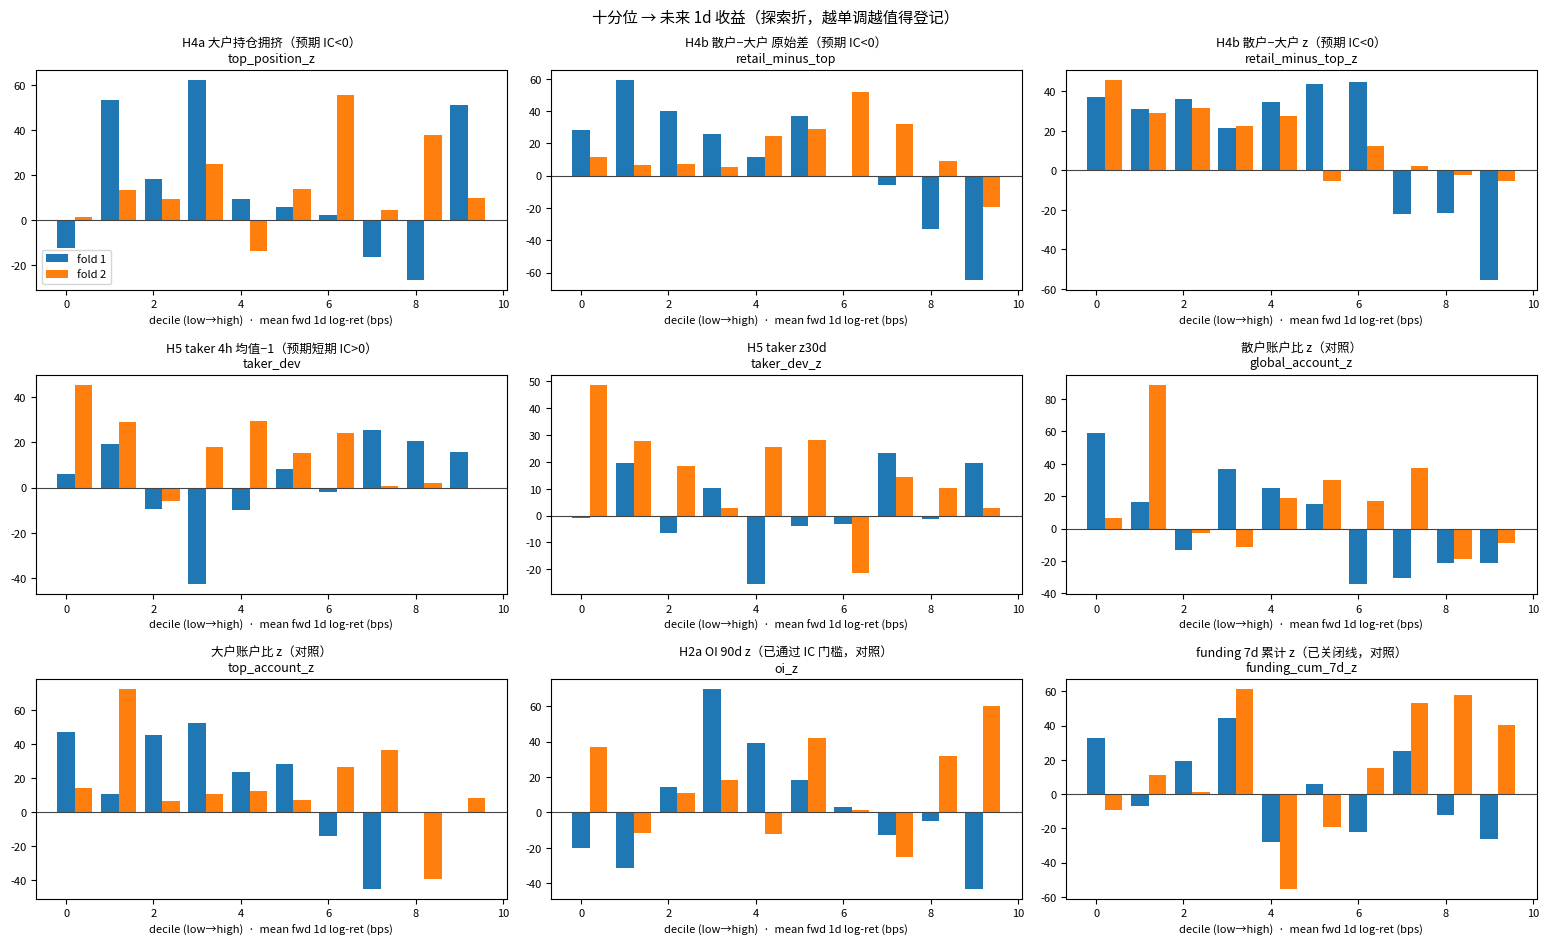

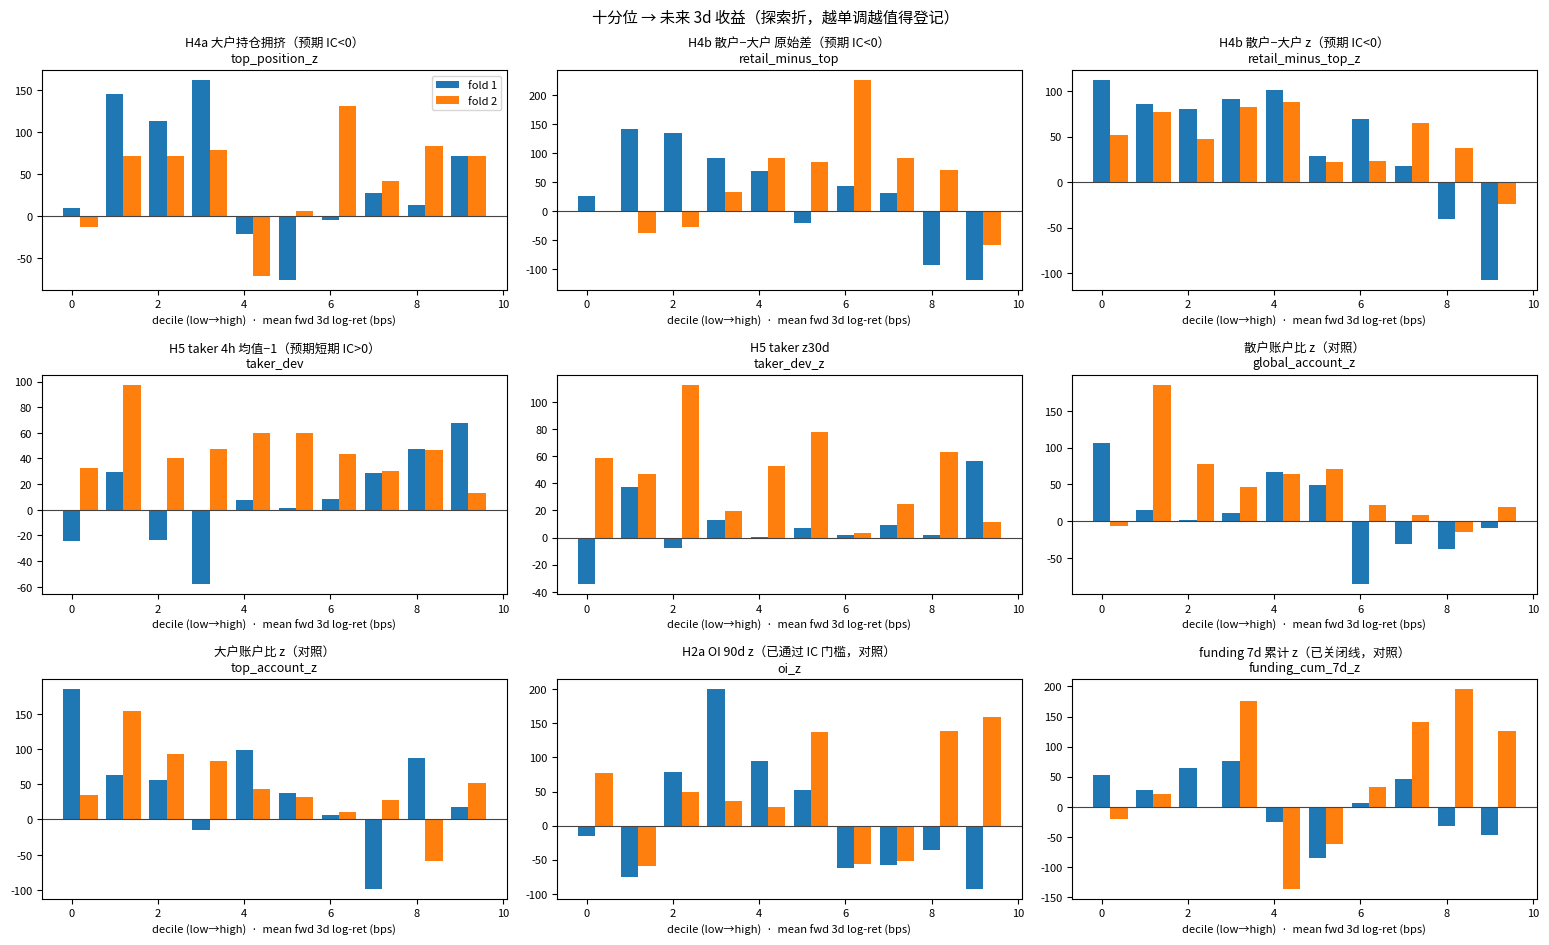

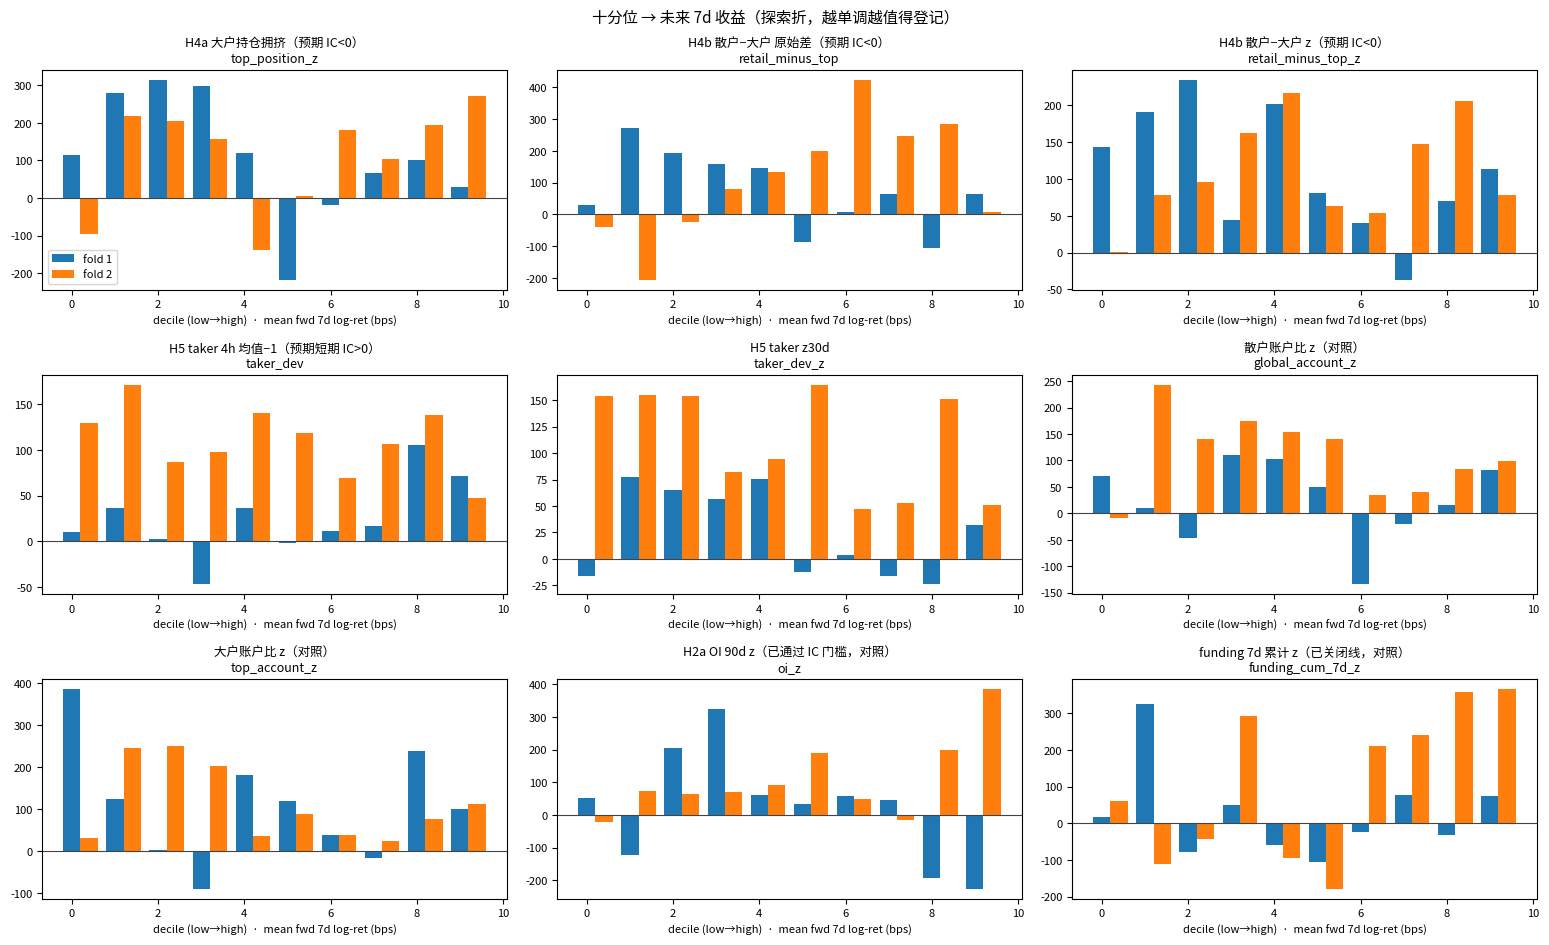

In [12]:
def decile_plot(features: dict, horizon: str, n_q: int = 10):
    n = len(features)
    ncol = 3
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5.2 * ncol, 3.2 * nrow), squeeze=False)
    fold_ids = sorted(explore["fold"].unique())
    width = 0.8 / len(fold_ids)
    for ax, (col, label) in zip(axes.ravel(), features.items()):
        for j, fid in enumerate(fold_ids):
            sub = explore[explore["fold"] == fid]
            s = sub[col]
            if s.notna().sum() < 100:
                continue
            q = pd.qcut(s.rank(method="first"), n_q, labels=False)
            mean_bps = sub.groupby(q)[f"fwd_{horizon}"].mean() * 1e4
            ax.bar(np.arange(n_q) + j * width, mean_bps.reindex(range(n_q)), width=width, label=f"fold {fid}")
        ax.axhline(0, color="#444", lw=0.8)
        ax.set_title(f"{label}\n{col}", fontsize=9)
        ax.set_xlabel(f"decile (low→high)  ·  mean fwd {horizon} log-ret (bps)", fontsize=8)
        ax.tick_params(labelsize=8)
    for ax in axes.ravel()[n:]:
        ax.axis("off")
    axes[0, 0].legend(fontsize=8)
    fig.suptitle(f"十分位 → 未来 {horizon} 收益（探索折，越单调越值得登记）", fontsize=11)
    fig.tight_layout()
    plt.show()

for hname in HORIZONS:
    decile_plot(CANDIDATES, hname)

### 5.1 regime 切分：gate off / gate on 但 V1 off / V1 on

H1 的教训：拥挤指标在震荡与强趋势里方向相反。这里看候选特征在三种状态下的**分布**和**未来 3 天收益的十分位形状**是否一致。规则真正会触发的是 `gate on` 的时段——那里才是要看的地方。

regime
gate off            2252
gate on / V1 off    1188
V1 on               2790
Name: count, dtype: int64


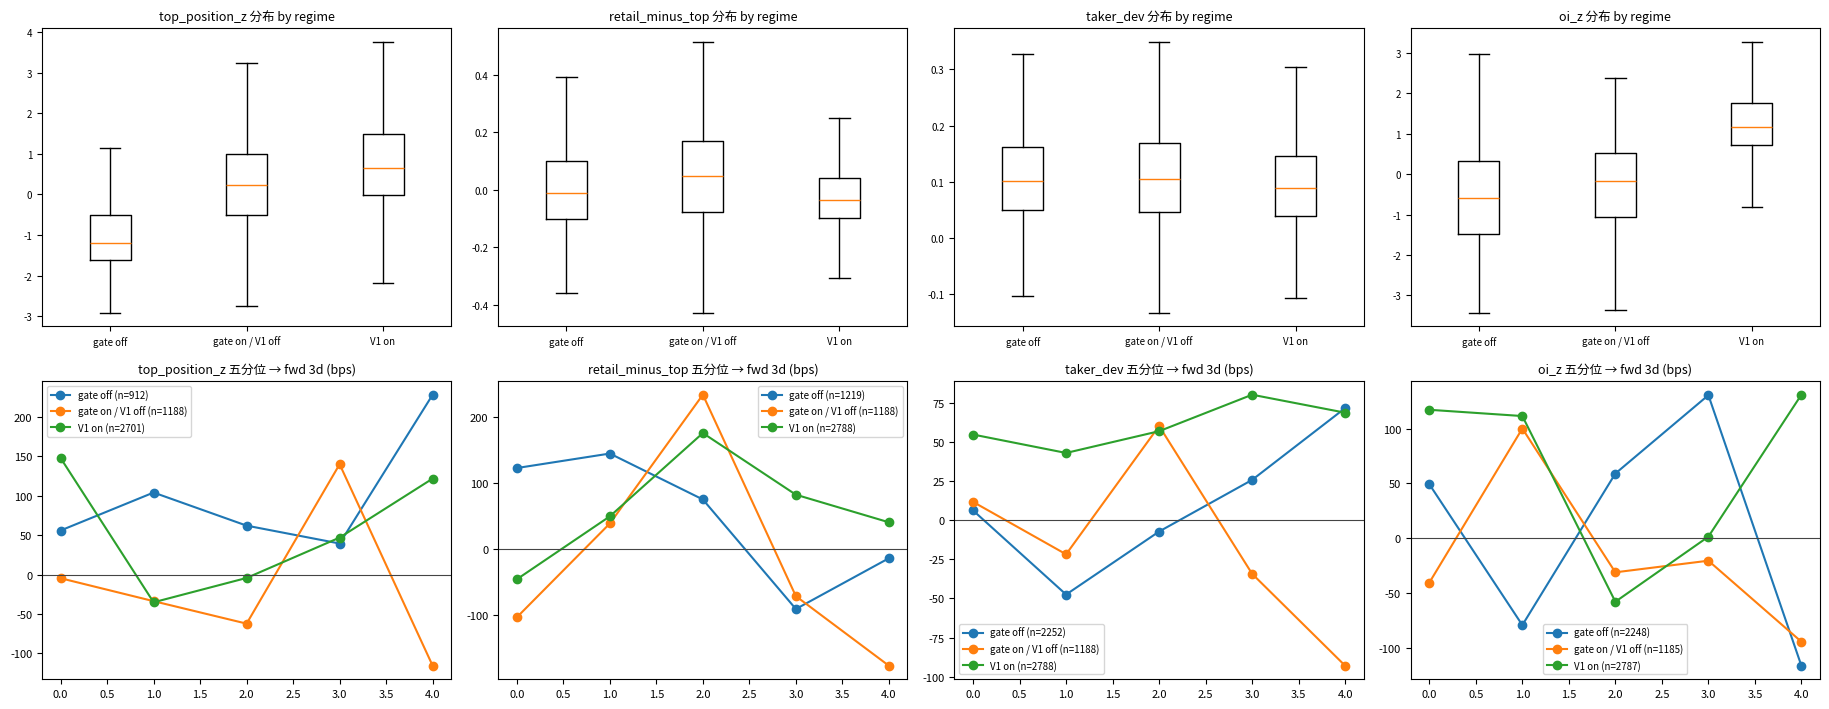

In [13]:
explore["regime"] = np.select(
    [explore["gate"] == 0, (explore["gate"] == 1) & (explore["v1"] == 0)],
    ["gate off", "gate on / V1 off"], default="V1 on")
REGIMES = ["gate off", "gate on / V1 off", "V1 on"]
print(explore["regime"].value_counts().reindex(REGIMES))

feats = ["top_position_z", "retail_minus_top", "taker_dev", "oi_z"]
fig, axes = plt.subplots(2, len(feats), figsize=(4.6 * len(feats), 7.2))
for j, col in enumerate(feats):
    ax = axes[0, j]
    data = [explore.loc[explore.regime == r, col].dropna() for r in REGIMES]
    ax.boxplot(data, tick_labels=REGIMES, showfliers=False)
    ax.set_title(f"{col} 分布 by regime", fontsize=9); ax.tick_params(labelsize=7)
    ax = axes[1, j]
    for r in REGIMES:
        sub = explore[explore.regime == r]
        if sub[col].notna().sum() < 300:
            continue
        q = pd.qcut(sub[col].rank(method="first"), 5, labels=False)
        ax.plot(sub.groupby(q)["fwd_3d"].mean() * 1e4, marker="o", label=f"{r} (n={sub[col].notna().sum()})")
    ax.axhline(0, color="#444", lw=0.8); ax.legend(fontsize=7)
    ax.set_title(f"{col} 五分位 → fwd 3d (bps)", fontsize=9); ax.tick_params(labelsize=8)
fig.tight_layout(); plt.show()

### 5.2 同源性检查：这些特征互相有多像？

设计文档要求：`top_position_z` 与 `oi_z` 的 Pearson > 0.95 → 二选一。顺带看 `retail_minus_top` 是否真是"OI 推不出的信息"。

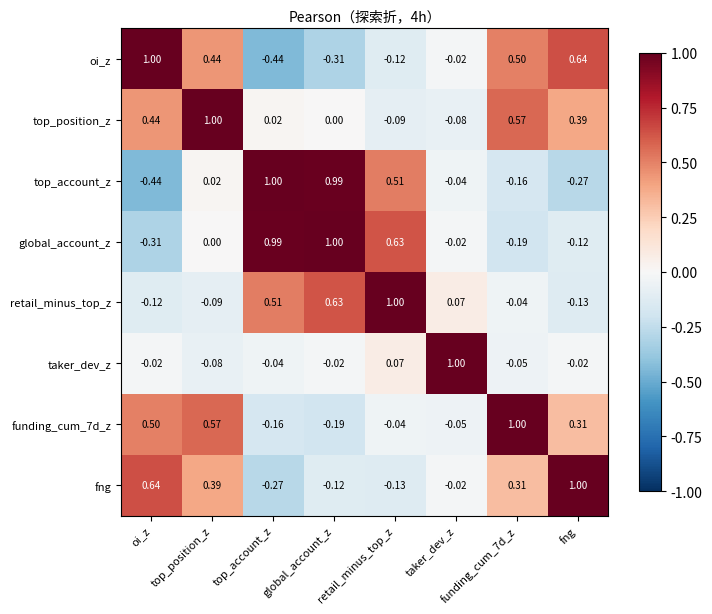

top_position_z vs oi_z Pearson = 0.444  (>0.95 则二选一)


In [14]:
corr_cols = ["oi_z", "top_position_z", "top_account_z", "global_account_z",
             "retail_minus_top_z", "taker_dev_z", "funding_cum_7d_z", "fng"]
corr = explore[corr_cols].corr()
fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr_cols)), corr_cols, fontsize=8)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(corr.iloc[i, j]) > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Pearson（探索折，4h）", fontsize=10)
fig.tight_layout(); plt.show()
print(f"top_position_z vs oi_z Pearson = {corr.loc['top_position_z', 'oi_z']:.3f}  (>0.95 则二选一)")

### 5.3 事件视角：极端值之后价格怎么走

把每个特征"进入极端区（|z| ≥ 2）"的时刻当事件，看事件后 0–14 天的平均累计对数收益（4h 步进）。只用探索折，事件之间至少间隔 3 天以免重复计数。

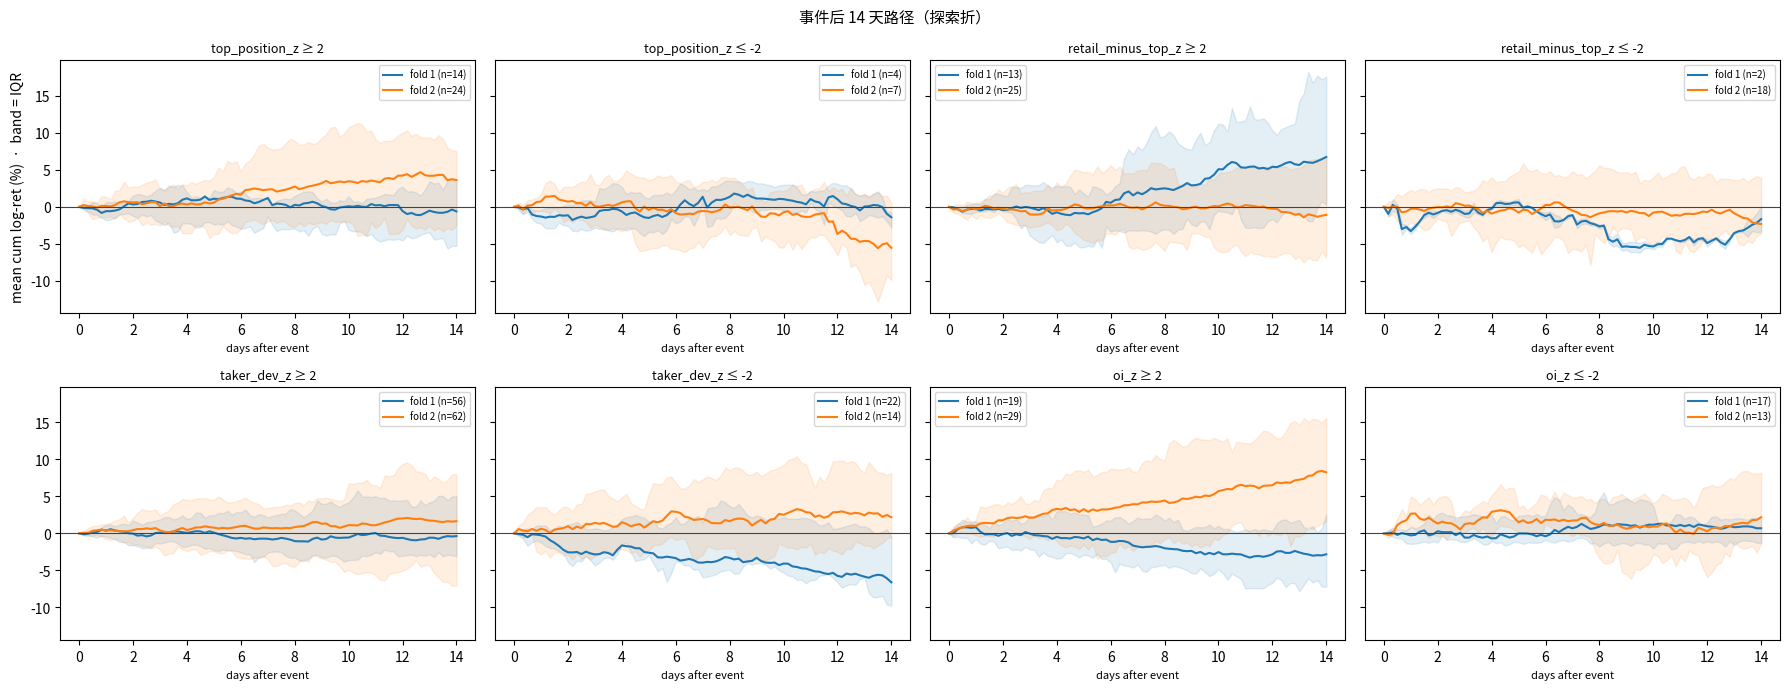

In [15]:
def event_paths(df: pd.DataFrame, cond: pd.Series, horizon_bars: int, min_gap_bars: int):
    idx = np.flatnonzero(cond.fillna(False).values)
    keep, last = [], -10**9
    for i in idx:
        if i - last >= min_gap_bars and i + horizon_bars < len(df):
            keep.append(i); last = i
    lc = df["log_close"].values
    paths = np.array([lc[i:i + horizon_bars + 1] - lc[i] for i in keep])
    return paths, len(keep)

H = 14 * BARS_PER_DAY
EVENTS = {
    "top_position_z ≥ 2":     explore["top_position_z"] >= 2,
    "top_position_z ≤ -2":    explore["top_position_z"] <= -2,
    "retail_minus_top_z ≥ 2": explore["retail_minus_top_z"] >= 2,
    "retail_minus_top_z ≤ -2":explore["retail_minus_top_z"] <= -2,
    "taker_dev_z ≥ 2":        explore["taker_dev_z"] >= 2,
    "taker_dev_z ≤ -2":       explore["taker_dev_z"] <= -2,
    "oi_z ≥ 2":               explore["oi_z"] >= 2,
    "oi_z ≤ -2":              explore["oi_z"] <= -2,
}
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharey=True)
x_days = np.arange(H + 1) / BARS_PER_DAY
ex = explore.reset_index(drop=True)
for ax, (label, cond) in zip(axes.ravel(), EVENTS.items()):
    for fid, color in ((1, "#1f77b4"), (2, "#ff7f0e")):
        sub = ex[ex.fold == fid].reset_index(drop=True)
        paths, n = event_paths(sub, cond.reset_index(drop=True)[ex.fold == fid].reset_index(drop=True), H, 3 * BARS_PER_DAY)
        if n == 0:
            continue
        ax.plot(x_days, paths.mean(0) * 100, color=color, label=f"fold {fid} (n={n})")
        ax.fill_between(x_days, np.percentile(paths, 25, 0) * 100, np.percentile(paths, 75, 0) * 100, color=color, alpha=0.12)
    ax.axhline(0, color="#444", lw=0.8); ax.set_title(label, fontsize=9); ax.legend(fontsize=7)
    ax.set_xlabel("days after event", fontsize=8)
axes[0, 0].set_ylabel("mean cum log-ret (%)  ·  band = IQR")
fig.suptitle("事件后 14 天路径（探索折）", fontsize=11); fig.tight_layout(); plt.show()

## 6. 观察记录（看完图在这里写）

> 规则：先写**方向 + 特征 + 时间尺度 + 预期在哪个 regime 起作用**，再去跑探针。写下来的东西不能因为探针结果改。

| # | 观察到的现象（哪段 episode / 哪张图） | 假设（特征 → 方向） | 属于 风控 / 收益增强 | 下一步 |
|---|---|---|---|---|
| 1 |  |  |  |  |
| 2 |  |  |  |  |

**已登记、待跑探针的三条**（设计文档 §8）：
- H4a `top_position` 90d z 极端高 → IC < 0（先查与 `oi_z` 同源性，见 §5.2）
- H4b `global_account − top_account` → IC < 0（优先级最高，OI 推不出的信息）
- H5 `taker_vol` 4h 均值偏离 1 的 z → 短期 IC > 0，中期反转；同时在 1d 尺度跑状态版

跑法（把特征加进 `scripts/signal_ic_probe.py` 的 `PROBE_FEATURES` 后）：
```bash
uv run python scripts/signal_ic_probe.py --config config/stage2_4h_signal_v2.yaml \
    --signals top_position_90d_z retail_minus_top taker_dev_z --horizons 6 18 42 --gate-on
```